# Machine Learning - Chapter 6

# Linear Regression

Linear Regression is a **supervised machine learning algorithm** used for predicting a **continuous numerical value**.

It learns the relationship between:

- **Independent variable / feature / input:** the value used for prediction
- **Dependent variable / target / output:** the value we want to predict

Example: predicting house price from house size, or predicting exam score from hours studied.

# Main Idea

Linear regression tries to find the **best-fit straight line** through the data.

For one feature, the line is:

$$\hat{y} = mx + b$$

Where:

- $\hat{y}$ = predicted value
- $x$ = input feature
- $m$ = slope / coefficient
- $b$ = intercept

The line is chosen so that the prediction errors are as small as possible.

# Best Fit Line

The **best fit line** is the line that minimizes the difference between actual values and predicted values.

Error for one point:

$$error = y - \hat{y}$$

The model tries to reduce total error across all data points.

A common method is minimizing **Mean Squared Error (MSE)**.

In [1]:
# Import Required Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# Sample Dataset

We will create a small dataset where study hours are used to predict exam scores.

In [2]:
data = {
    'Hours_Studied': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'Exam_Score': [35, 42, 50, 55, 63, 67, 75, 80, 88, 95]
}

df = pd.DataFrame(data)
df

,Hours_Studied,Exam_Score
0,1,35
1,2,42
2,3,50
3,4,55
4,5,63
5,6,67
6,7,75
7,8,80
8,9,88
9,10,95


# Visualizing the Relationship

Before training a linear regression model, always check if the relationship looks roughly linear.

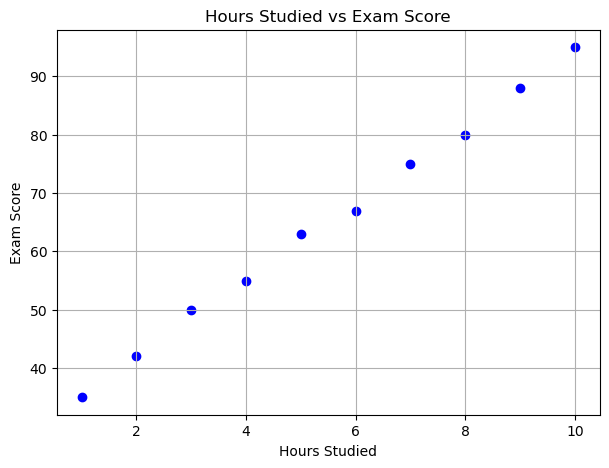

In [3]:
plt.figure(figsize=(7, 5))
plt.scatter(df['Hours_Studied'], df['Exam_Score'], color='blue')
plt.title('Hours Studied vs Exam Score')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.grid(True)
plt.show()

# Simple Linear Regression

Simple Linear Regression uses **one independent variable** to predict one continuous target.

Formula:

$$\hat{y} = \theta_0 + \theta_1x$$

Where:

- $\theta_0$ = intercept
- $\theta_1$ = coefficient / slope
- $x$ = feature value

In [4]:
X = df[['Hours_Studied']]
y = df['Exam_Score']

model = LinearRegression()
model.fit(X, y)

print('Coefficient / Slope:', model.coef_[0])
print('Intercept:', model.intercept_)

Coefficient / Slope: 6.52121212121212
Intercept: 29.13333333333334


# Prediction

After training, the model can predict the target value for new input values.

In [5]:
hours = pd.DataFrame({'Hours_Studied': [7.5]})
predicted_score = model.predict(hours)

print('Predicted score for 7.5 hours of study:', predicted_score[0])

Predicted score for 7.5 hours of study: 78.04242424242423


# Regression Line

The fitted regression line shows the predictions made by the model.

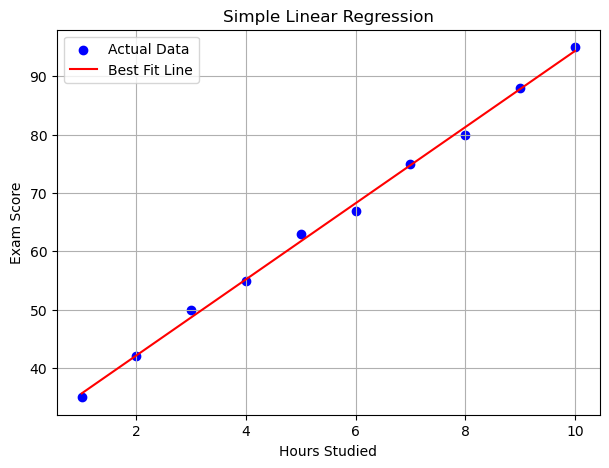

In [6]:
y_pred = model.predict(X)

plt.figure(figsize=(7, 5))
plt.scatter(X, y, color='blue', label='Actual Data')
plt.plot(X, y_pred, color='red', label='Best Fit Line')
plt.title('Simple Linear Regression')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.legend()
plt.grid(True)
plt.show()

# Multiple Linear Regression

Multiple Linear Regression uses **more than one independent variable**.

Formula:

$$\hat{y} = \theta_0 + \theta_1x_1 + \theta_2x_2 + \cdots + \theta_nx_n$$

Example: predicting house price using area, number of bedrooms, age of house, and location score.

In [7]:
house_data = {
    'Area_sqft': [800, 1000, 1200, 1500, 1800, 2000, 2200, 2500, 2800, 3000],
    'Bedrooms': [1, 2, 2, 3, 3, 3, 4, 4, 4, 5],
    'House_Age': [12, 10, 8, 7, 5, 4, 3, 2, 1, 1],
    'Price_Lakhs': [35, 45, 52, 68, 82, 90, 105, 120, 135, 150]
}

house_df = pd.DataFrame(house_data)
house_df

,Area_sqft,Bedrooms,House_Age,Price_Lakhs
0,800,1,12,35
1,1000,2,10,45
2,1200,2,8,52
3,1500,3,7,68
4,1800,3,5,82
5,2000,3,4,90
6,2200,4,3,105
7,2500,4,2,120
8,2800,4,1,135
9,3000,5,1,150


In [8]:
X_house = house_df[['Area_sqft', 'Bedrooms', 'House_Age']]
y_house = house_df['Price_Lakhs']

multi_model = LinearRegression()
multi_model.fit(X_house, y_house)

print('Coefficients:', multi_model.coef_)
print('Intercept:', multi_model.intercept_)

Coefficients: [0.06102062 3.09521119 2.85774827]
Intercept: -51.25999434945611


In [9]:
new_house = pd.DataFrame({
    'Area_sqft': [1600],
    'Bedrooms': [3],
    'House_Age': [6]
})

predicted_price = multi_model.predict(new_house)
print('Predicted house price in lakhs:', predicted_price[0])

Predicted house price in lakhs: 72.80512784291987


# Cost Function

The cost function tells us how wrong the model is.

For linear regression, the most common cost function is **Mean Squared Error (MSE)**:

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Lower MSE means better predictions.

# Evaluation Metrics

Common regression metrics:

- **MAE:** Mean Absolute Error. Average absolute difference between actual and predicted values.
- **MSE:** Mean Squared Error. Average squared difference between actual and predicted values.
- **RMSE:** Root Mean Squared Error. Square root of MSE, measured in the same unit as the target.
- **R-squared:** Shows how much variation in the target is explained by the model.

In [10]:
mae = mean_absolute_error(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y, y_pred)

print('MAE:', mae)
print('MSE:', mse)
print('RMSE:', rmse)
print('R-squared:', r2)

MAE: 0.7224242424242441
MSE: 0.7587878787878772
RMSE: 0.8710843121006584
R-squared: 0.9978419002309787


# Train-Test Split

In real machine learning, we do not evaluate the model only on the same data used for training.

We split data into:

- **Training set:** used to train the model
- **Testing set:** used to check how well the model performs on unseen data

In [11]:
np.random.seed(42)

area = np.random.randint(500, 3500, 100)
bedrooms = np.random.randint(1, 6, 100)
age = np.random.randint(1, 30, 100)

price = 0.05 * area + 8 * bedrooms - 0.7 * age + np.random.normal(0, 10, 100)

realistic_df = pd.DataFrame({
    'Area_sqft': area,
    'Bedrooms': bedrooms,
    'House_Age': age,
    'Price_Lakhs': price
})

realistic_df.head()

,Area_sqft,Bedrooms,House_Age,Price_Lakhs
0,1360,4,1,97.870091
1,1794,3,19,81.054298
2,1630,3,2,105.606590
3,1595,1,21,72.892851
4,2138,3,12,109.199259


In [12]:
X = realistic_df[['Area_sqft', 'Bedrooms', 'House_Age']]
y = realistic_df['Price_Lakhs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

test_model = LinearRegression()
test_model.fit(X_train, y_train)

test_predictions = test_model.predict(X_test)

print('Test MAE:', mean_absolute_error(y_test, test_predictions))
print('Test RMSE:', np.sqrt(mean_squared_error(y_test, test_predictions)))
print('Test R-squared:', r2_score(y_test, test_predictions))

Test MAE: 7.836188362569051
Test RMSE: 10.052037989300707
Test R-squared: 0.9429181905919148


# Assumptions of Linear Regression

Linear regression works best when these assumptions are mostly true:

1. **Linearity:** input and output have a linear relationship.
2. **Independence:** errors are independent of each other.
3. **Homoscedasticity:** errors have constant variance.
4. **Normality of errors:** residuals are roughly normally distributed.
5. **No multicollinearity:** features should not be highly correlated with each other.
6. **No autocorrelation:** errors should not follow repeating patterns.

# Residuals

A **residual** is the difference between actual and predicted value.

$$residual = y - \hat{y}$$

Residual plots help us check whether the model is making systematic mistakes.

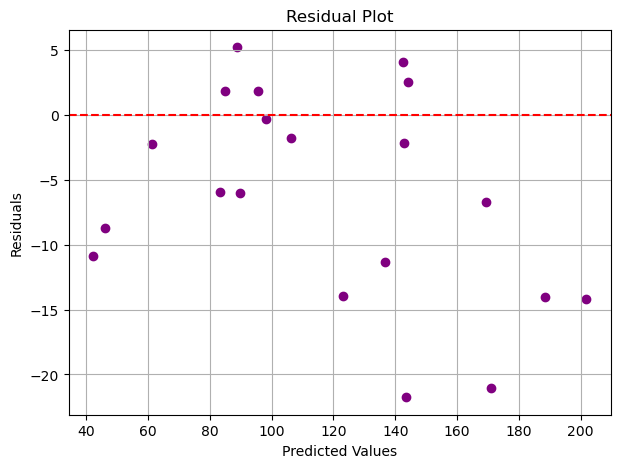

In [13]:
residuals = y_test - test_predictions

plt.figure(figsize=(7, 5))
plt.scatter(test_predictions, residuals, color='purple')
plt.axhline(y=0, color='red', linestyle='--')
plt.title('Residual Plot')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

# Regularization

Regularization is used to reduce overfitting by adding a penalty for large coefficients.

Main types:

- **Ridge Regression:** L2 regularization, penalizes squared coefficients.
- **Lasso Regression:** L1 regularization, can shrink some coefficients to zero.
- **Elastic Net:** combination of L1 and L2 regularization.

Regularization is useful when there are many features or when features are highly correlated.

In [14]:
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)

models = {
    'Linear Regression': test_model,
    'Ridge Regression': ridge_model,
    'Lasso Regression': lasso_model,
    'Elastic Net': elastic_model
}

for name, reg_model in models.items():
    reg_model.fit(X_train, y_train)
    preds = reg_model.predict(X_test)
    print(name)
    print('RMSE:', np.sqrt(mean_squared_error(y_test, preds)))
    print('R-squared:', r2_score(y_test, preds))
    print()

Linear Regression
RMSE: 10.052037989300707
R-squared: 0.9429181905919148

Ridge Regression
RMSE: 10.051383098957754
R-squared: 0.9429256281101674

Lasso Regression
RMSE: 10.047351543842924
R-squared: 0.9429714033687621

Elastic Net
RMSE: 10.050352990938478
R-squared: 0.9429373259541228



# Advantages of Linear Regression

- Simple and easy to understand.
- Fast to train and predict.
- Coefficients are interpretable.
- Good baseline model for regression problems.
- Works well when the relationship is truly linear.

# Limitations of Linear Regression

- Assumes a linear relationship.
- Sensitive to outliers.
- Can perform poorly if important non-linear patterns exist.
- Multicollinearity can make coefficients unstable.
- Feature scaling and feature engineering may be needed for better performance.

# Important Terms

| Term | Meaning |
|---|---|
| Feature | Input variable used for prediction |
| Target | Output variable to be predicted |
| Coefficient | Weight learned for a feature |
| Intercept | Predicted value when all inputs are zero |
| Residual | Actual value minus predicted value |
| MSE | Average squared error |
| RMSE | Square root of MSE |
| R-squared | Percentage of variation explained by model |

# Practice Questions

1. What is the difference between simple and multiple linear regression?
2. Why do we square errors in Mean Squared Error?
3. What does the slope represent in linear regression?
4. What is the purpose of train-test split?
5. Why is multicollinearity a problem?
6. When would Ridge Regression be better than normal Linear Regression?
7. What does an R-squared value close to 1 mean?

# Chapter Summary

- Linear Regression predicts continuous numerical values.
- It finds a best-fit line that minimizes prediction error.
- Simple Linear Regression uses one feature.
- Multiple Linear Regression uses multiple features.
- MAE, MSE, RMSE, and R-squared are used to evaluate regression models.
- Residuals help us understand model errors.
- Ridge, Lasso, and Elastic Net are regularized versions of linear regression.
- Linear regression is simple, interpretable, and a strong baseline for regression problems.